# 05 – Echte Lagersignale: vom Rohsignal zu Merkmalen
**Ziel:** Eine Messkurve wird zu einer Zeile einer ML-Tabelle. Wir sehen echte Sensordaten, betrachten Umdrehungen, berechnen eine FFT und erzeugen Merkmale je Messfenster.

Wir verwenden eine kleine Auswahl aus dem **CWRU Bearing Data Center**: vier DE-Beschleunigungssignale bei 0 HP Last, ungefähr 1797 U/min und 48 kHz. Gesund, Innenring-, Kugel- und Außenringfehler (0,007 Zoll; Außenring bei 6 Uhr). Die Schäden wurden im Labor künstlich eingebracht; die gemessenen Signale sind real.

**Voraussetzung:** pandas/NumPy-Grundlagen. Kein Modelltraining. Dauer: ca. 45–60 Minuten.

Quellen: [Versuchsaufbau](https://engineering.case.edu/bearingdatacenter/apparatus-and-procedures), [gesunde Referenz](https://engineering.case.edu/bearingdatacenter/normal-baseline-data), [48-kHz-Fehleraufnahmen](https://engineering.case.edu/bearingdatacenter/48k-drive-end-bearing-fault-data).

## 1. Laden: eine Datei ist eine Aufnahme, keine Tabellenzeile
Beim ersten Start werden nur `97.mat`, `109.mat`, `122.mat` und `135.mat` direkt von CWRU geladen (wenige MB pro Datei). Danach funktioniert das Beispiel offline aus `daten/cwru`. Bei einem gesperrten Download nennt die Fehlermeldung den Link und den Ablageort.

Die kleine Hilfsdatei `sensor_features.py` bündelt Laden und Feature-Berechnung; die wichtigen Schritte bauen wir hier sichtbar auf. `DE_time` bezeichnet die Zeitreihe des Sensors am antriebsseitigen Lager. Die Abtastrate kommt aus der gewählten Datenserie, nicht aus dem Variablennamen.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Start aus dem Repository, Set-Ordner oder einem Übungsordner möglich.
kandidaten = [Path.cwd(), *Path.cwd().parents]
set_ordner = next((p for basis in kandidaten
                   for p in (basis, basis / "set3-datenanalyse-und-visualisierung")
                   if (p / "sensor_features.py").exists()), None)
if set_ordner is None:
    raise FileNotFoundError("Bitte das Notebook innerhalb des Kursordners starten.")
if str(set_ordner) not in sys.path:
    sys.path.insert(0, str(set_ordner))
from sensor_features import FS, lade_aufnahmen, spektrum, signal_merkmale, erstelle_feature_tabelle

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})

In [2]:
signale, metadata = lade_aufnahmen()
display(metadata.drop(columns=["url", "sha256"]).round(3))
print("Messwerte pro Sekunde:", FS)

,aufnahme,zustand,fs_hz,rpm,rpm_quelle,samples,dauer_s
0,97,gesund,48000,1796.0,Datei,243938,5.082
1,109,Innenring,48000,1796.0,Datei,243938,5.082
2,122,Kugel,48000,1796.0,Datei,244739,5.099
3,135,Außenring,48000,1796.0,Datei,243538,5.074


Messwerte pro Sekunde: 48000


## 2. Rohsignale vergleichen
Wir betrachten jeweils die ersten 0,1 Sekunden mit gleicher y-Skala. Eine Zeile in der Rohaufnahme ist ein Zeitpunkt, noch kein Maschinenzustand als ML-Sample. Aus dem Signal wollen wir später Stärke, Impulsivität und Frequenzverteilung beschreiben.

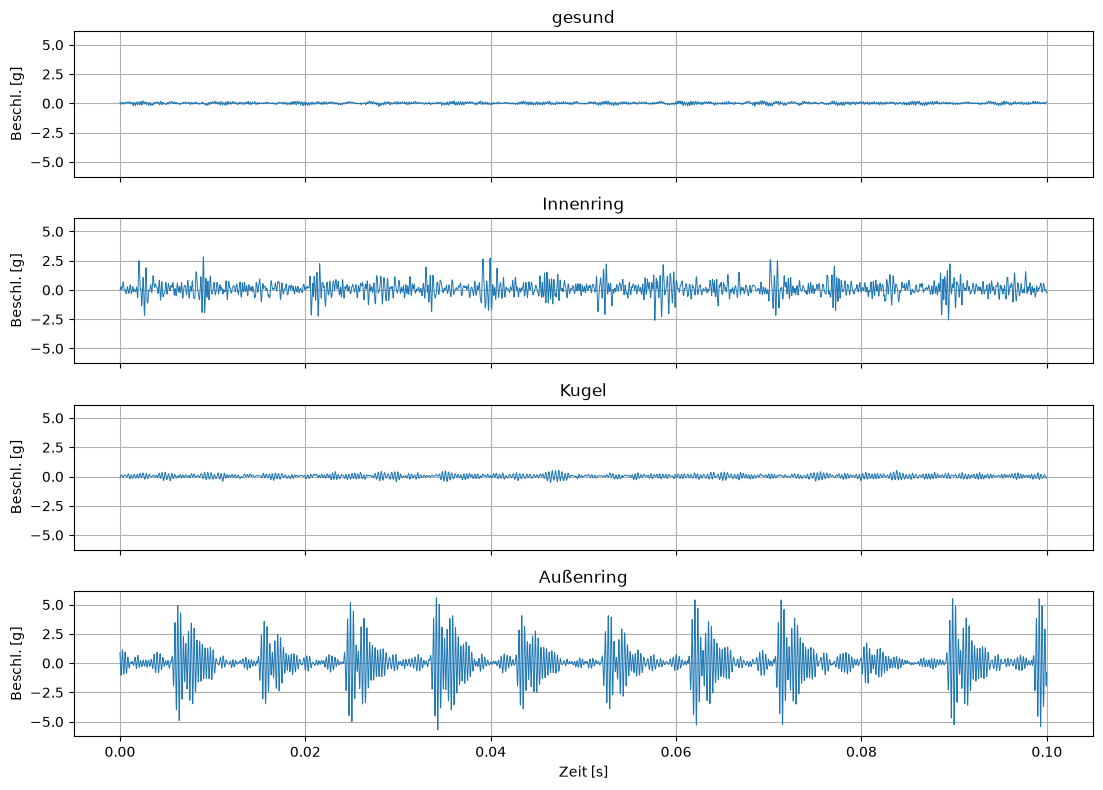

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, (zustand, x) in zip(axes, signale.items()):
    n = int(0.1 * FS)
    ax.plot(np.arange(n) / FS, x[:n], linewidth=0.7)
    ax.set_title(zustand)
    ax.set_ylabel("Beschl. [g]")
axes[-1].set_xlabel("Zeit [s]")
plt.tight_layout(); plt.show()

## 3. Was bedeutet „pro Zyklus“ bei einem Lager?
Hier gibt es **keine markierten Produktionszyklen und keinen Tachopuls**. Eine Wellenumdrehung ist näherungsweise ein mechanischer Zyklus. Bei 1797 U/min dauert sie `60 / 1797 ≈ 0,0334 s`. Aus der mittleren Drehzahl können wir Umdrehungsfenster schätzen. Ihr Beginn ist willkürlich und nicht winkelgenau synchronisiert; langfristig kann die Phase driften.

Eine Umdrehung enthält viele Messwerte. Wir zeichnen drei geschätzte Umdrehungen übereinander und bilden je Umdrehung ein erstes Merkmal. Für echte Produktionszyklen bräuchten wir Start-/Endmarkierungen; bei variabler Drehzahl wäre eine winkelbasierte Auswertung nötig.

Ca. 1603.6 Samples pro Umdrehung


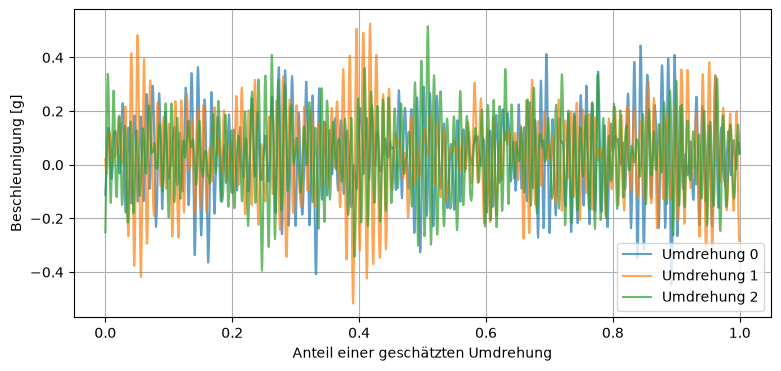

,umdrehung,rms,peak
0,0,0.143931,0.479234
1,1,0.154674,0.550026
2,2,0.140584,0.483720
3,3,0.155150,0.487727
4,4,0.150284,0.487993


In [4]:
zustand = "Kugel"
x = signale[zustand]
rpm = metadata.loc[metadata.zustand == zustand, "rpm"].iloc[0]
samples_pro_umdrehung = FS * 60 / rpm
grenzen = np.rint(np.arange(13) * samples_pro_umdrehung).astype(int)
zyklen = [x[a:b] for a, b in zip(grenzen[:-1], grenzen[1:])]
print(f"Ca. {samples_pro_umdrehung:.1f} Samples pro Umdrehung")
for i, zyklus in enumerate(zyklen[:3]):
    plt.plot(np.arange(len(zyklus)) / len(zyklus), zyklus, alpha=0.7, label=f"Umdrehung {i}")
plt.xlabel("Anteil einer geschätzten Umdrehung"); plt.ylabel("Beschleunigung [g]")
plt.legend(); plt.show()
zyklus_tabelle = pd.DataFrame({
    "umdrehung": range(len(zyklen)),
    "rms": [np.sqrt(np.mean((z - z.mean()) ** 2)) for z in zyklen],
    "peak": [np.max(np.abs(z - z.mean())) for z in zyklen],
})
display(zyklus_tabelle.head())

## 4. FFT: Welche Frequenzen stecken im Signal?
Die FFT zerlegt ein Signal in Frequenzanteile. Für die Darstellung verwenden wir ein **Hann-Fenster**: Es schwächt die Ränder ab und vermindert die Verteilung eines Frequenzanteils auf benachbarte Bins (Leakage). Vorher ziehen wir den Mittelwert ab.

Wir nehmen **8192 Samples ≈ 0,171 s ≈ fünf Umdrehungen**. Die Frequenzauflösung beträgt `fs / N ≈ 5,86 Hz`; bei einer einzigen Umdrehung wäre sie nur ungefähr 30 Hz. Größeres N verbessert die Frequenzauflösung, vermindert aber die zeitliche Auflösung. Oberhalb von `fs / 2 = 24 kHz` können wir keine Frequenzen darstellen.

Die einseitige Amplitude wird mit der Summe des Hann-Fensters normiert und für positive Frequenzen verdoppelt. DC und Nyquist bleiben einfach. Die Darstellung ist ein Amplitudenspektrum, keine Leistungsdichte.

Fensterdauer: 0.171 s; Frequenzabstand: 5.86 Hz


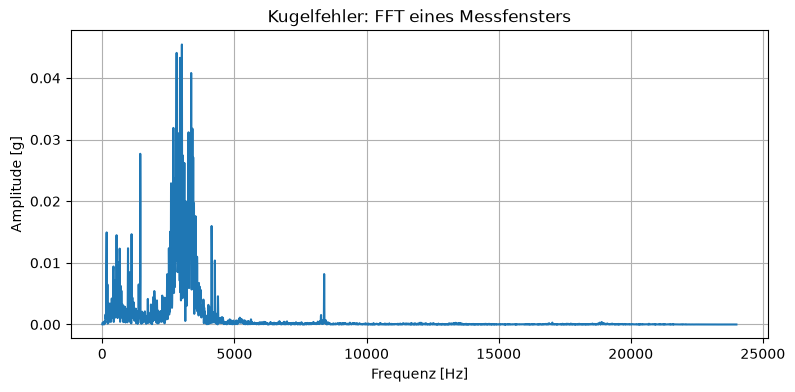

In [5]:
N = 8192
segment = signale["Kugel"][:N]
zentriert = segment - segment.mean()
hann = np.hanning(N)
fft = np.fft.rfft(zentriert * hann)
frequenzen = np.fft.rfftfreq(N, d=1 / FS)
amplitude = np.abs(fft) / hann.sum()
amplitude[1:-1] *= 2
print(f"Fensterdauer: {N / FS:.3f} s; Frequenzabstand: {FS / N:.2f} Hz")
plt.plot(frequenzen, amplitude)
plt.xlabel("Frequenz [Hz]"); plt.ylabel("Amplitude [g]")
plt.title("Kugelfehler: FFT eines Messfensters"); plt.show()

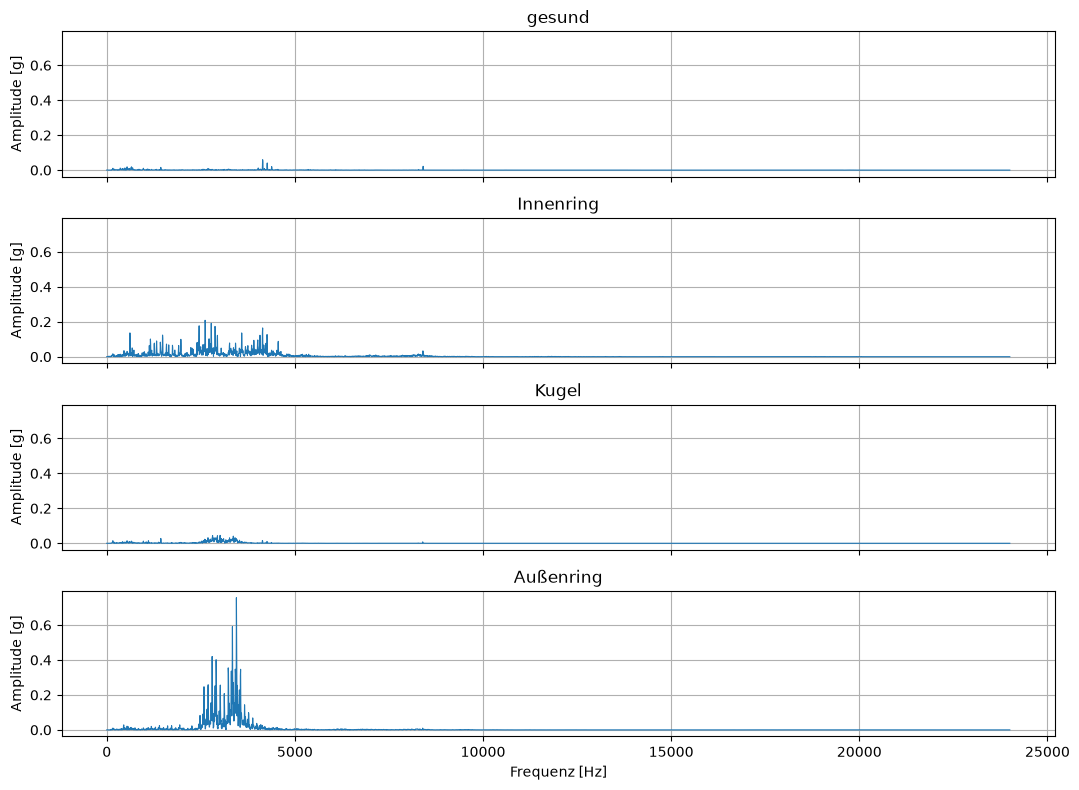

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, (zustand, x) in zip(axes, signale.items()):
    f, a = spektrum(x[:N])
    ax.plot(f, a, linewidth=0.8)
    ax.set_title(zustand); ax.set_ylabel("Amplitude [g]")
axes[-1].set_xlabel("Frequenz [Hz]")
plt.tight_layout(); plt.show()

**Beobachtungsauftrag:** Welche Signale haben stärkere Peaks? Liegt die Energie überwiegend im gleichen Frequenzbereich? Ein Spektralpeak ist nicht automatisch eine Lagerfehlerfrequenz: Resonanzen, Drehzahl und Last beeinflussen das Spektrum. Für eine physikalische Diagnose wären Lagergeometrie und oft eine Hüllkurvenanalyse nötig.

## 5. Feature Engineering im Zeitbereich
Wir komprimieren Tausende Messpunkte zu wenigen Zahlen. Die folgenden Zeitmerkmale berechnen wir nach Mittelwertabzug.

| Merkmal | Bedeutung |
|---|---|
| RMS | Effektivwert: Stärke der Schwingung |
| mittlerer Absolutwert | alternative Beschreibung der Schwingungsstärke |
| Peak / Peak-to-Peak | stärkster Ausschlag / gesamte Spannweite |
| Crest-Faktor = Peak / RMS | große Einzelspitzen relativ zum Grundniveau |
| Kurtosis | Impulsivität; hier Pearson-Kurtosis (Normalverteilung ≈ 3) |

RMS und mittlerer Absolutwert dürften häufig zusammenhängen. Diese Redundanz schauen wir uns im nächsten Notebook an.

In [7]:
rms = np.sqrt(np.mean(zentriert ** 2))
peak = np.max(np.abs(zentriert))
print(f"RMS: {rms:.4f} g; Peak: {peak:.4f} g; Crest-Faktor: {peak / rms:.2f}")

RMS: 0.1487 g; Peak: 0.5497 g; Crest-Faktor: 3.70


## 6. Features aus dem Frequenzbereich
Wir addieren quadrierte FFT-Beträge in breiten Frequenzbändern und teilen durch die Summe über alle Bins. Das gibt einen **relativen spektralen Energieanteil**. Die vier Bänder decken das ganze Spektrum ab und ihre Anteile summieren sich auf 1. Das sind bewusst einfache Lernmerkmale, keine universellen Diagnosegrenzen.

Der Spektralschwerpunkt ist die mit spektraler Energie gewichtete mittlere Frequenz. Die Peak-Frequenz ist die Frequenz mit der größten Amplitude. Diese Merkmale beschreiben die Form des Spektrums statt nur dessen Höhe.

In [8]:
energie = np.abs(fft) ** 2
energie[1:-1] *= 2
maske = (frequenzen >= 1000) & (frequenzen < 3000)
print(f"Energieanteil 1–3 kHz: {energie[maske].sum() / energie.sum():.1%}")
display(pd.Series(signal_merkmale(segment), name="Merkmalswert").to_frame())

Energieanteil 1–3 kHz: 47.5%


,Merkmalswert
rms,0.148685
mittel_abs,0.118346
peak,0.549688
peak_to_peak,1.043494
crest_faktor,3.696983
kurtosis,3.071860
spektralschwerpunkt_hz,2897.919353
peak_frequenz_hz,3011.718750
band_0_1000,0.042414
band_1000_3000,0.474862


## 7. Eine ML-Tabelle: eine Zeile pro Messfenster
Wir schneiden **nicht überlappende** Fenster aus jeder Aufnahme. Für einen übersichtlichen Vergleich nehmen wir jeweils 24 Fenster. Aufnahme-ID, Zustand und Zeit bleiben Metadaten; nur die berechneten Zahlen werden Eingangsmerkmale.

Viele Fenster aus derselben Aufnahme sind **keine unabhängigen Versuche**. Wir machen hier explorative Analyse. Für späteres Modelltraining dürfen Fenster derselben Aufnahme nicht zufällig auf Training und Test verteilt werden; man benötigt zusätzliche unabhängige Aufnahmen und trennt nach Aufnahme/Lager. Vier Aufnahmen reichen nicht für einen belastbaren Klassifikationsnachweis.

In [9]:
features = erstelle_feature_tabelle(signale, metadata, fenster_samples=N)
merkmal_spalten = features.columns.drop(["aufnahme", "zustand", "fenster", "start_s"]).tolist()
print("Form:", features.shape)
display(features.head().round(4))
display(features.groupby("zustand")[merkmal_spalten].mean().round(3))

Form:

 (96, 16)


,aufnahme,zustand,fenster,start_s,rms,mittel_abs,peak,peak_to_peak,crest_faktor,kurtosis,spektralschwerpunkt_hz,peak_frequenz_hz,band_0_1000,band_1000_3000,band_3000_6000,band_6000_24000
0,97,gesund,0,0.0000,0.0742,0.0594,0.2846,0.5203,3.8365,2.8777,3376.1841,4142.5781,0.2317,0.0827,0.6348,0.0508
1,97,gesund,1,0.1707,0.0713,0.0573,0.2482,0.4615,3.4813,2.8040,3602.3300,4142.5781,0.1627,0.1021,0.6782,0.0570
2,97,gesund,2,0.3413,0.0725,0.0587,0.2503,0.4865,3.4506,2.7194,3484.4118,4142.5781,0.2039,0.0860,0.6533,0.0568
3,97,gesund,3,0.5120,0.0729,0.0592,0.2966,0.5182,4.0679,2.7177,3472.6976,4142.5781,0.2052,0.0848,0.6564,0.0537
4,97,gesund,4,0.6827,0.0714,0.0575,0.2524,0.4679,3.5363,2.7488,3503.1081,4142.5781,0.2054,0.0845,0.6498,0.0603


,rms,mittel_abs,peak,peak_to_peak,crest_faktor,kurtosis,spektralschwerpunkt_hz,peak_frequenz_hz,band_0_1000,band_1000_3000,band_3000_6000,band_6000_24000
zustand,,,,,,,,,,,,
Außenring,1.250,0.786,5.899,11.643,4.719,6.713,3248.605,3445.312,0.001,0.234,0.764,0.001
Innenring,0.583,0.415,3.018,5.716,5.181,6.046,2861.391,2532.959,0.052,0.593,0.345,0.010
Kugel,0.146,0.116,0.568,1.085,3.894,3.112,2895.195,3103.027,0.048,0.453,0.497,0.002
gesund,0.073,0.059,0.256,0.486,3.530,2.765,3486.454,4142.578,0.200,0.091,0.653,0.056


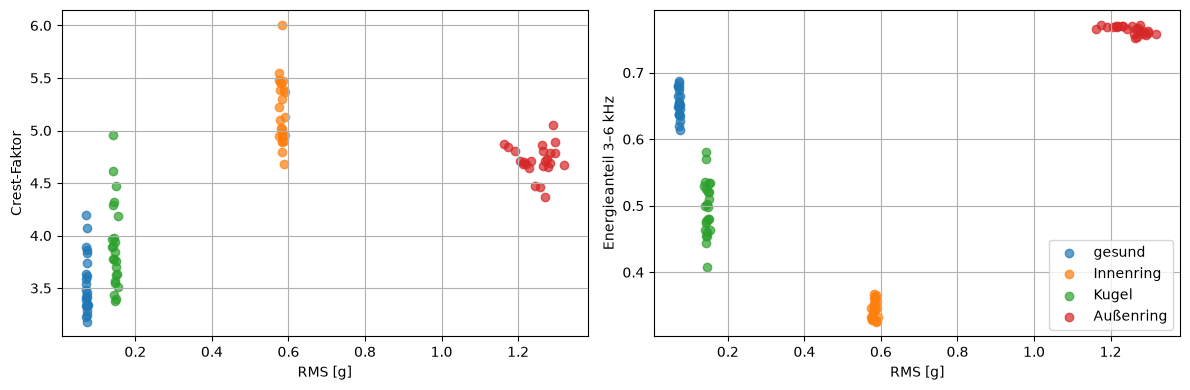

In [10]:
farben = {"gesund": "tab:blue", "Innenring": "tab:orange", "Kugel": "tab:green", "Außenring": "tab:red"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for zustand, gruppe in features.groupby("zustand", sort=False):
    axes[0].scatter(gruppe.rms, gruppe.crest_faktor, label=zustand, color=farben[zustand], alpha=0.7)
    axes[1].scatter(gruppe.rms, gruppe.band_3000_6000, label=zustand, color=farben[zustand], alpha=0.7)
axes[0].set(xlabel="RMS [g]", ylabel="Crest-Faktor")
axes[1].set(xlabel="RMS [g]", ylabel="Energieanteil 3–6 kHz")
axes[1].legend(); plt.tight_layout(); plt.show()

## Zum Ausprobieren
1. Ändere `N` auf 4096 oder 16384 und berechne FFT und Feature-Tabelle erneut. Wie ändern sich Frequenzauflösung und Anzahl vollständiger Fenster?
2. Vergleiche die FFT mit und ohne Hann-Fenster. Weshalb verändert sich das Spektrum?
3. Ergänze den Median der Absolutwerte als robustes Zeitmerkmal.
4. Welche Unterschiede sieht man erst mit Frequenzmerkmalen und welche schon mit RMS?

**Weiter:** `06_pca_sensor_features.ipynb` erzeugt dieselbe Tabelle selbstständig und untersucht, welche Merkmale ähnliche Information tragen.